# SAC
이 튜토리얼은 **Soft Actor-Critic (SAC)** 알고리즘을 구현하는 방법을 안내한다.

**SAC (Soft Actor-Critic)**는 DDPG나 TD3와 같은 연속적인 행동 공간을 위한 알고리즘이지만, **최대 엔트로피(Maximum Entropy)** 강화학습 프레임워크를 기반으로 한다. 즉, 에이전트는 보상뿐만 아니라 행동의 **무작위성(Entropy)도 함께 최대화**하려고 한다. 이를 통해 에이전트는 한 가지 행동에 고착되지 않고 다양한 시도를 하며 더 강건하고 안정적인 학습을 할 수 있다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 기준으로 작성되었으며, 복잡한 설치 과정 없이 실행 가능한 `LunarLanderContinuous-v2` 환경을 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions.normal import Normal
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Actor & Critic 네트워크 생성 (Create Actor & Critic Networks)

SAC는 **Stochastic Policy (확률적 정책)**를 사용한다.

1. **Actor (Policy Network)**: 상태를 입력받아 행동 분포의 **평균(Mean)**과 **표준편차(Std)**를 출력한다. 이를 통해 가우시안 분포(Gaussian Distribution)를 만들고 행동을 샘플링한다. 여기서 **Reparameterization Trick**을 사용하여 역전파가 가능하게 만든다.
2. **Critic (Soft Q-Network)**: TD3와 마찬가지로 2개의 Critic을 사용하여 Q값의 과대평가를 방지한다.

In [4]:
class Actor(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim, max_action):
        """
        Actor 네트워크: 상태 -> 평균(Mean), 표준편차(Log Std) 출력
        """
        super().__init__()
        self.max_action = float(max_action)

        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        self.mean_layer = nn.Linear(hidden_size, action_dim)
        self.log_std_layer = nn.Linear(hidden_size, action_dim)

    def forward(self, state):
        x = self.net(state)
        mean = self.mean_layer(x)
        log_std = self.log_std_layer(x)

        # 표준편차 값의 범위를 제한 (안정적인 학습을 위해)
        log_std = torch.clamp(log_std, -20, 2)
        std = torch.exp(log_std)

        # 가우시안 분포 생성
        dist = Normal(mean, std)

        # Reparameterization Trick (rsample): 샘플링을 하면서도 미분 가능하게 함
        z = dist.rsample()

        # Tanh를 적용하여 행동 범위를 -1 ~ 1로 제한
        action = torch.tanh(z)

        # Log Probability 계산 (Tanh 변환에 따른 보정항 추가)
        # log_prob = log_prob_normal - log(1 - tanh(z)^2)
        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        return action * self.max_action, log_prob

class SoftQNetwork(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim):
        """
        Critic 네트워크: 상태 + 행동 -> Q값
        2개의 Q-net을 사용하여 Min 값을 취함
        """
        super().__init__()

        # Q1 architecture
        self.net1 = nn.Sequential(
            nn.Linear(obs_size + action_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

        # Q2 architecture
        self.net2 = nn.Sequential(
            nn.Linear(obs_size + action_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        return self.net1(x), self.net2(x)

### 5. 경험 리플레이 버퍼 (Replay Buffer)

일반적인 리플레이 버퍼를 사용한다.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (SAC 알고리즘 구현)

SAC의 학습 로직을 구현한다.

* **Entropy Regularization**: 보상 함수에 엔트로피 항()이 추가된다.
* **Alpha ()**: 엔트로피의 중요도를 조절하는 온도 파라미터다. 높을수록 탐험을 많이 한다.
* **Target Value Calculation**: 다음 상태의 가치를 계산할 때, 다음 상태에서 샘플링한 행동의 Q값에서 엔트로피 항을 뺀다.
*

In [6]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=256, lr=3e-4,
                 capacity=100000, gamma=0.99, batch_size=256, tau=0.005, alpha=0.2):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.alpha = alpha  # Entropy coefficient (Temperature)

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]
        max_action = self.env.action_space.high[0]

        # 네트워크 초기화
        self.actor = Actor(obs_size, hidden_size, action_dim, max_action).to(device)
        self.critic = SoftQNetwork(obs_size, hidden_size, action_dim).to(device)
        self.critic_target = copy.deepcopy(self.critic).to(device)

        # 최적화기
        self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=lr)
        self.critic_optimizer = optim.AdamW(self.critic.parameters(), lr=lr)

        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state):
        """행동 샘플링 (학습 중에는 확률적으로, 테스트 시에는 평균값 사용 가능)"""
        state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
        with torch.no_grad():
            action, _ = self.actor(state_t)
        return action.cpu().numpy()[0]

    def soft_update(self, net, target_net):
        for param, target_param in zip(net.parameters(), target_net.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0, 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.float32, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)

        # ----------------------------
        # 1. Critic 업데이트
        # ----------------------------
        with torch.no_grad():
            # 다음 상태에서 행동 샘플링 (Current Policy 사용)
            next_actions, next_log_probs = self.actor(next_states)

            # 타겟 Q값 계산
            target_q1, target_q2 = self.critic_target(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2)

            # Soft Critic Update: 엔트로피 항(alpha * log_prob)을 뺌
            # y = r + gamma * (min_Q - alpha * log_pi)
            soft_target_q = target_q - self.alpha * next_log_probs
            y_target = rewards + (1 - dones) * self.gamma * soft_target_q

        # 현재 Q값
        current_q1, current_q2 = self.critic(states, actions)

        # Critic 손실
        critic_loss = F.mse_loss(current_q1, y_target) + F.mse_loss(current_q2, y_target)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # ----------------------------
        # 2. Actor 업데이트
        # ----------------------------
        # Reparameterization Trick을 사용하여 행동 샘플링
        new_actions, log_probs = self.actor(states)
        q1, q2 = self.critic(states, new_actions)
        min_q = torch.min(q1, q2)

        # Actor 손실: 엔트로피 최대화 + Q값 최대화
        # Loss = alpha * log_pi - Q
        actor_loss = (self.alpha * log_probs - min_q).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # ----------------------------
        # 3. 타겟 네트워크 업데이트
        # ----------------------------
        self.soft_update(self.critic, self.critic_target)

        return critic_loss.item(), actor_loss.item()

    def run_training(self, max_episodes=600, max_steps=1000):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            for step in range(max_steps):
                action = self.get_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            total_rewards.append(episode_reward)

            if episode % 10 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}")

        return total_rewards

    def save_video(self, filename="sac_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

SAC 에이전트를 생성하고 학습을 시작한다. SAC는 별도의 탐험 노이즈(Epsilon 등) 설정 없이도 엔트로피 항 덕분에 자동으로 탐험과 이용의 균형을 맞춘다.

In [8]:
# SAC 모델 생성
agent = PytorchWrapper(
    'LunarLanderContinuous-v3',
    hidden_size=256,
    lr=3e-4,
    batch_size=256,
    alpha=0.2 # Temperature parameter
)

# 학습 시작
print("SAC (Soft Actor-Critic) 학습을 시작한다...")
history = agent.run_training(max_episodes=500)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


SAC (Soft Actor-Critic) 학습을 시작한다...
Episode 0, Reward: -335.83
Episode 10, Reward: -315.00
Episode 20, Reward: -101.50
Episode 30, Reward: -145.38
Episode 40, Reward: -62.31
Episode 50, Reward: -58.92
Episode 60, Reward: -103.69
Episode 70, Reward: -47.82
Episode 80, Reward: -80.28
Episode 90, Reward: -71.65
Episode 100, Reward: -52.39
Episode 110, Reward: -66.13
Episode 120, Reward: -65.91
Episode 130, Reward: -51.15
Episode 140, Reward: -54.63
Episode 150, Reward: -46.70
Episode 160, Reward: -71.03
Episode 170, Reward: -16.50
Episode 180, Reward: -19.58
Episode 190, Reward: -47.95
Episode 200, Reward: -18.60
Episode 210, Reward: -5.55
Episode 220, Reward: 0.30
Episode 230, Reward: -4.95
Episode 240, Reward: -12.22
Episode 250, Reward: -34.27
Episode 260, Reward: -11.72
Episode 270, Reward: 1.98
Episode 280, Reward: 24.37
Episode 290, Reward: 70.66
Episode 300, Reward: 238.52
Episode 310, Reward: 243.45
Episode 320, Reward: 268.78
Episode 330, Reward: 54.85
Episode 340, Reward: 118.83

### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

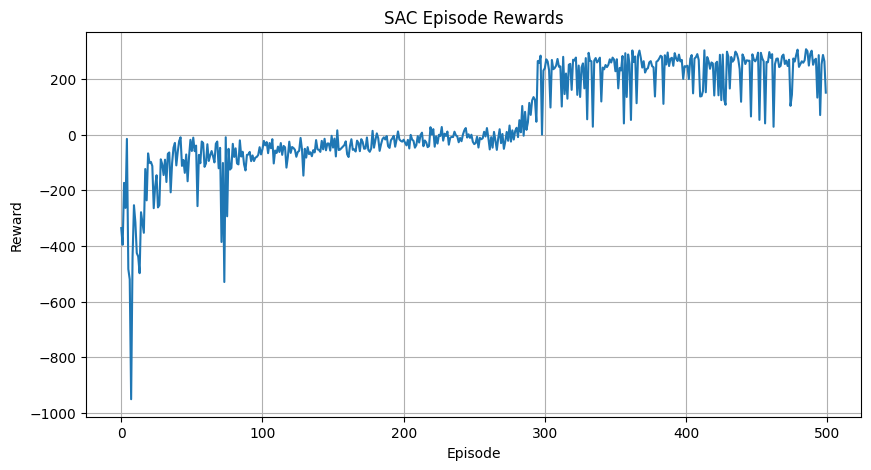

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("SAC Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("sac")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")